In [4]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.9/69.5 MB 21.5 MB/s eta 0:00:04
   --- ------------------------------------ 5.8/69.5 MB 15.3 MB/s eta 0:00:05
   ---- ----------------------------------- 8.1/69.5 MB 14.1 MB/s eta 0:00:05
   ----- ---------------------------------- 10.2/69.5 MB 12.6 MB/s eta 0:00:05
   ------- -------------------------------- 12.3/69.5 MB 12.1 MB/s eta 0:00:05
   -------- ------------------------------- 14.4/69.5 MB 11.9 MB/s eta 0:00:05
   --------- ------------------------------ 17.0/69.5 MB 11.9 MB/s eta 0:00:05
   ----------- ---------------------------- 19.7/69.5 MB 12.0 MB/s eta 0:00:05
   ------------ --------------------------- 22.5/69.5 MB 12.2 MB/s eta 0:00:04
   -------------- ------------------------- 25.7/69.5 MB 12.4 MB/s eta 0:00:04
   ---------------- ----------------------- 28.6/69.5 MB 12.4 MB/s eta 0:00:04
   ----------------- ---------------------- 30.9/69.5 MB 12.3 M

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [3]:
house_price_dataset = sklearn.datasets.fetch_california_housing()

In [6]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [7]:
df = pd.DataFrame(house_price_dataset.data ,columns = house_price_dataset.feature_names)

In [8]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [12]:
df['price'] = house_price_dataset.target

In [13]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [14]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

Understanding the correlation between various features in the dataset
  1. Positive Correlation

  2. Negative Correlation

In [18]:
correlation = df.corr()

In [19]:
print(correlation)

              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
price       0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

            Latitude  Longitude     price  
MedInc     -0.079809  -0.015176  0.688075  
HouseAge    0.011173  -0.108197  0.105623  
AveRooms    0.106389  -0.027540  0.151948  
AveBedrms   0.069721   0.013344 -0.046701  
Populatio

<Axes: >

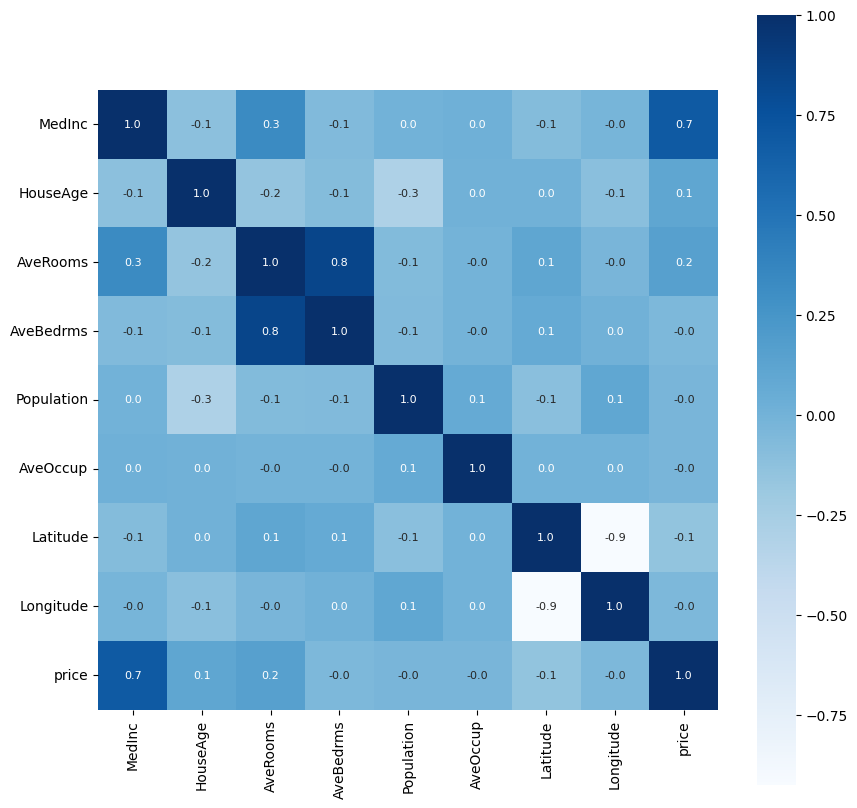

In [35]:
# constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar = True,square = True , fmt ='.1f' , annot = True , annot_kws ={'size':8},cmap ='Blues')

Splitting the data and Target

In [36]:
X = df.drop(['price'],axis =1)
Y = df['price']

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

Model Training : XGBRegressor

In [38]:
model = XGBRegressor()

In [39]:
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Model Evaluation

In [40]:
training_data_prediction = model.predict(X_train)

In [41]:
print(training_data_prediction)

[0.53758794 2.9007688  0.6848911  ... 1.7890452  1.9554564  0.7771621 ]


In [43]:
# R square error
score_1 = metrics.r2_score(Y_train, training_data_prediction)

score_2 = metrics.mean_absolute_error(Y_train,training_data_prediction)

score_3 = metrics.root_mean_squared_error(Y_train , training_data_prediction)

print('R square error : ',score_1)
print('Mean Absolute error :', score_2)
print('Mean Square erro',score_3)

R square error :  0.947186443380359
Mean Absolute error : 0.18885009247854148
Mean Square erro 0.2647950623930754


accuracy_score() মূলত Classification-এর জন্য, আর r2_score() মূলত Regression-এর জন্য ব্যবহৃত হয়।

Visualizing the actual Prices and predicted prices

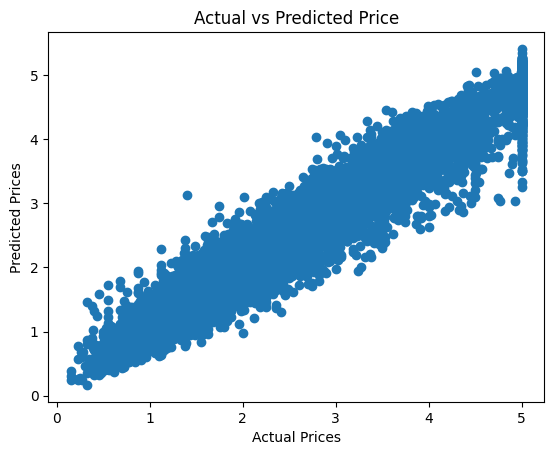

In [44]:
plt.scatter(Y_train , training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Price")
plt.show()

Prediction on test Data

In [45]:
test_data_prediction = model.predict(X_test)

In [46]:
# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8370813165448978
Mean Absolute Error :  0.3079223702763229
